# Display a map of google

In [1]:
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt

In [4]:
# Load roads directly from local Limburg OpenStreetMap PBF file
pbf_path = Path("limburg-260312.osm.pbf")
if not pbf_path.exists():
    raise FileNotFoundError(f"Could not find: {pbf_path.resolve()}")

roads = gpd.read_file(pbf_path, layer="lines")

# Project for cleaner plotting in meters
roads = roads.to_crs(epsg=3857)

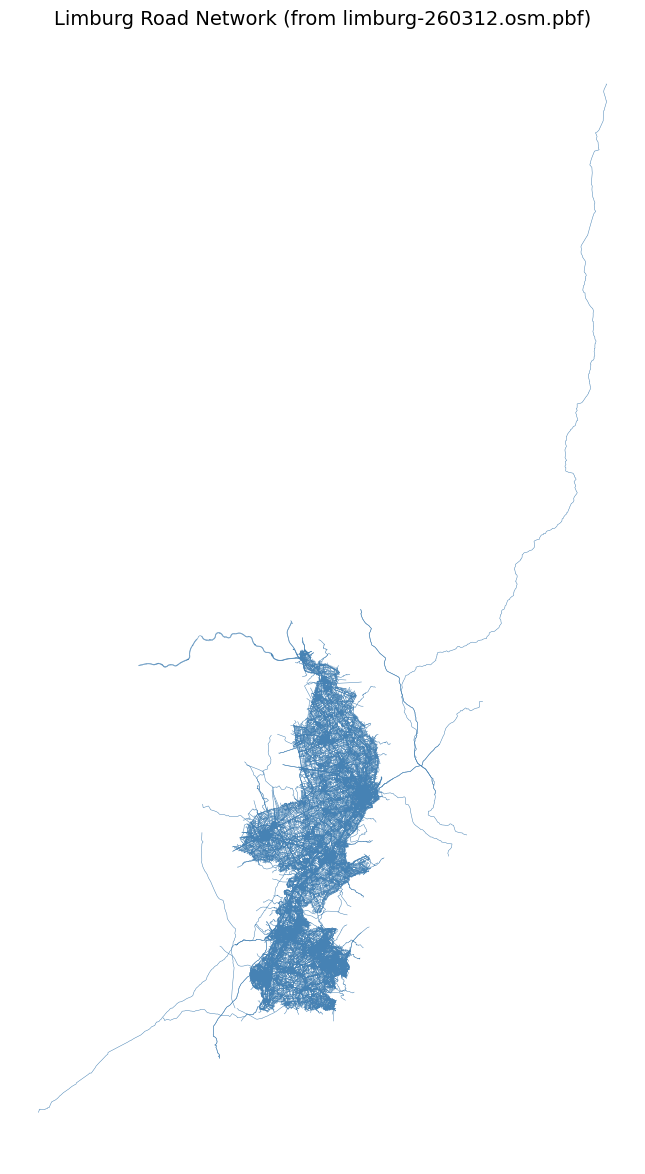

In [5]:
fig, ax = plt.subplots(figsize=(12, 12))
roads.plot(ax=ax, linewidth=0.35, color="steelblue")
ax.set_title("Limburg Road Network (from limburg-260312.osm.pbf)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

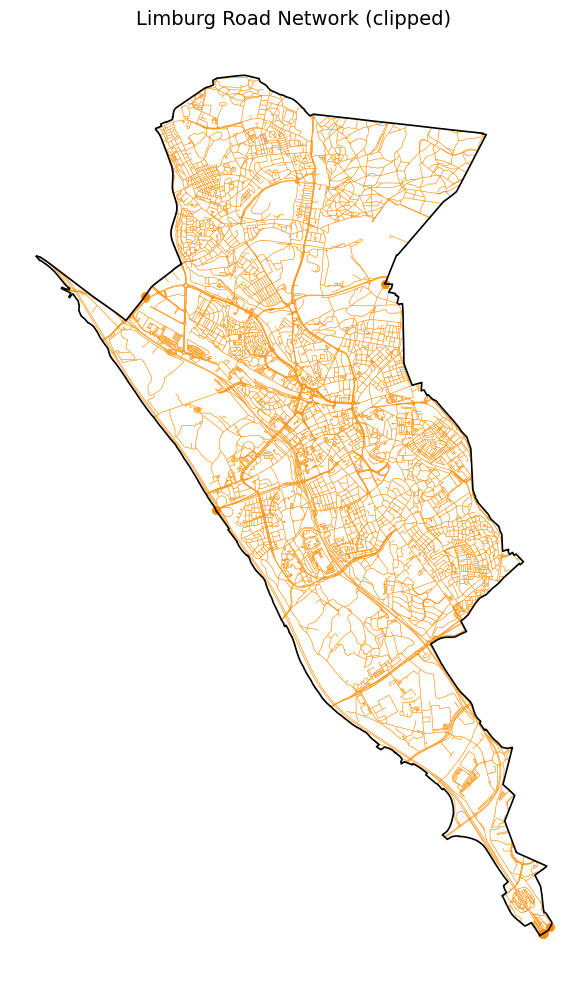

Road segments after clipping: 10,181


In [6]:
import osmnx as ox

# Build Limburg boundary and clip roads to it
limburg_boundary = ox.geocode_to_gdf("Heerlen, Limburg, Netherlands")
limburg_boundary = limburg_boundary.to_crs(roads.crs)
limburg_geom = limburg_boundary.union_all()

# Keep road-like lines and cut segments at the Limburg border
if "highway" in roads.columns:
    roads_for_plot = roads[roads["highway"].notna()].copy()
else:
    roads_for_plot = roads.copy()

roads_limburg = gpd.clip(roads_for_plot, limburg_geom)
roads_limburg = roads_limburg[roads_limburg.geometry.notna() & ~roads_limburg.geometry.is_empty].copy()

fig, ax = plt.subplots(figsize=(10, 10))
roads_limburg.plot(ax=ax, linewidth=0.45, color="darkorange")
limburg_boundary.boundary.plot(ax=ax, linewidth=1.2, color="black")
ax.set_title("Limburg Road Network (clipped)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

print(f"Road segments after clipping: {len(roads_limburg):,}")

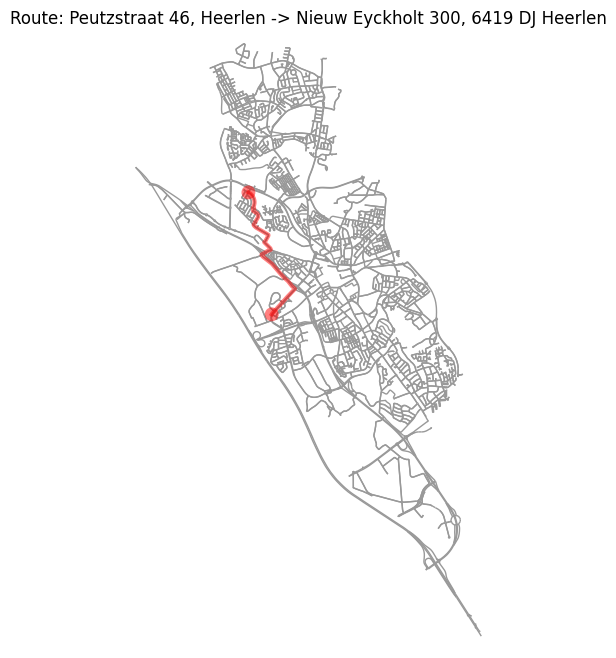

In [13]:
# Set your route endpoints here
start_point = "Peutzstraat 46, Heerlen"
destination = "Nieuw Eyckholt 300, 6419 DJ Heerlen"

# Build a drivable graph for Heerlen and geocode the two endpoints
route_graph = ox.graph_from_place("Heerlen, Limburg, Netherlands", network_type="drive")
start_lat, start_lon = ox.geocode(start_point)
end_lat, end_lon = ox.geocode(destination)

# Snap endpoints to nearest road nodes and compute shortest path by length
start_node = ox.distance.nearest_nodes(route_graph, X=start_lon, Y=start_lat)
end_node = ox.distance.nearest_nodes(route_graph, X=end_lon, Y=end_lat)
route = ox.shortest_path(route_graph, start_node, end_node, weight="length")

# Plot the route
fig, ax = ox.plot_graph_route(
    route_graph,
    route,
    route_color="red",
    route_linewidth=3,
    node_size=0,
    bgcolor="white",
    show=False,
    close=False,
)
ax.set_title(f"Route: {start_point} -> {destination}", fontsize=12)
plt.show()

In [6]:
import osmnx as ox

G = ox.graph_from_place("Heerlen, Limburg, Netherlands", network_type="drive")
nodes, edges = ox.graph_to_gdfs(G)

print("Nodes:", len(nodes))
print("Edges:", len(edges))
print("Node columns:", list(nodes.columns))
print("Edge columns:", list(edges.columns))
print(edges[["name", "highway", "length"]].head())

Nodes: 2926
Edges: 6824
Node columns: ['y', 'x', 'street_count', 'highway', 'ref', 'geometry']
Edge columns: ['osmid', 'highway', 'lanes', 'maxspeed', 'oneway', 'ref', 'reversed', 'length', 'geometry', 'bridge', 'junction', 'name', 'access', 'tunnel', 'width']
                       name        highway      length
u        v         key                                
41941190 41940361  0    NaN       motorway  184.415130
41941240 712758381 0    NaN  motorway_link   37.950937
41941852 41941190  0    NaN  motorway_link   46.927499
41942044 41944458  0    NaN       motorway  300.546619
         41942494  0    NaN  motorway_link   58.733325


In [14]:
ox.geocode("Peutzstraat 46, Heerlen")

(50.9034726, 5.9546005)